In [1]:
%reload_ext autoreload
%autoreload 2

# import all the functions from the fastfeedback module
from fastfeedback import *
from tqdm import tqdm

In [2]:
#Loading the CAFs data

data_manager = DataManager("/storage/1/st15719/caf_new_sum.2.6M_weighted.root")

Loading data...


/software/oz22897/miniconda/envs/dune-atmo-osc/lib/python3.12/site-packages/awkward/_nplikes/array_module.py:454: RuntimeWarning: invalid value encountered in cast
  return self._module.concatenate(arrays, axis=axis, casting="same_kind")


Finished loading data


In [3]:
#Defining the binning for the true and reco energy and coszenith
Ebins = np.logspace(-1, 1, 200)
Czbins = np.linspace(-1, 1, 100)
Ebins_reco = np.logspace(-1, 1, 50)
Czbins_reco = np.linspace(-1, 1, 20)

latex_names = {
    Flavor.NuE: r"$\nu_e$",
    Flavor.NuMu: r"$\nu_\mu$",
    Flavor.NuMuBar: r"$\bar{\nu}_\mu$",
    Flavor.NuEBar: r"$\bar{\nu}_e$",
    Flavor.NuTau: r"$\bar{\nu}_\tau$",
    Flavor.NuTauBar: r"$\bar{\nu}_\tau$",
}

In [4]:
#Preparing the data with the default settings, of the current reco performances
def plot_data(method: int):
    direc_reco = Method.Truth if method & 1 << 0 else Method.Reco
    energy_reco = Method.Truth if method & 1 << 1 else Method.Reco
    flavor_disc = Method.Truth if method & 1 << 2 else Method.Reco
    nunubar_disc = Method.Truth if method & 1 << 3 else Method.Reco

    data_manager.set_direc_reco(direc_reco)
    data_manager.set_energy_reco(energy_reco)
    data_manager.set_flavor_discrimination(flavor_disc)
    data_manager.set_nunubar_discrimination(nunubar_disc)

    data = data_manager.prepare_data()

    #Creating the events distribution
    events = EventDistrib(data, Ebins, Czbins, Ebins_reco, Czbins_reco)

    null_hyps = [
        get_nufit(MH.Normal),
        get_nufit(MH.Normal),
        get_nufit(MH.Inverted),
        get_nufit(MH.Inverted)
    ]
    null_hyps[0].dcp = 0
    null_hyps[1].dcp = np.pi/2
    null_hyps[2].dcp = 0
    null_hyps[3].dcp = np.pi/2

    ref_event_rates = []

    for null_hyp in null_hyps:
        events.compute_osc(null_hyp)
        ref_event_rates.append({fl: events.detected_events(fl) for fl in events.detected_channels})

    LnL_values_nofit = [[] for _ in range(len(null_hyps))]
    dcp_scan = np.linspace(-np.pi, np.pi, 40)
    for dcp in dcp_scan:
        alt_hyp = get_nufit(MH.Normal)
        alt_hyp.dcp = dcp

        events.compute_osc(alt_hyp)

        expected = {fl: events.detected_events(fl) for fl in events.detected_channels}

        for i, null_hyp in enumerate(null_hyps):
            #Computing the LnL values
            llh = 0
            for ch in events.detected_channels:
                llh += LnL(ref_event_rates[i][ch], expected[ch])
            LnL_values_nofit[i].append(llh)
        
    plt.figure()
    plt.plot(dcp_scan, LnL_values_nofit[0], label="NH, dcp=0")
    plt.plot(dcp_scan, LnL_values_nofit[1], label="NH, dcp=π/2")
    plt.plot(dcp_scan, LnL_values_nofit[2], label="IH, dcp=0")
    plt.plot(dcp_scan, LnL_values_nofit[3], label="IH, dcp=π/2")

    plt.xlabel(r"$\delta_{CP}$")
    plt.ylabel("Log likelihood")
    plt.title(f"Direction={direc_reco.name}, Energy={energy_reco.name}, Flavor={flavor_disc.name}, Nu-Nubar={nunubar_disc.name}")
    plt.legend()
    plt.show()

  0%|          | 0/16 [00:00<?, ?it/s]

Filling histograms...
Using the following detected output channels: ['NC', 'NuE', 'NuMu']
Finished filling histograms...


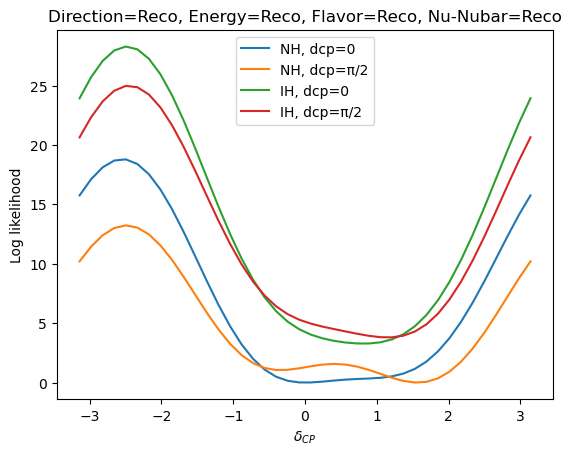

  6%|▋         | 1/16 [00:43<10:46, 43.10s/it]

Filling histograms...
Using the following detected output channels: ['NC', 'NuE', 'NuMu']
Finished filling histograms...


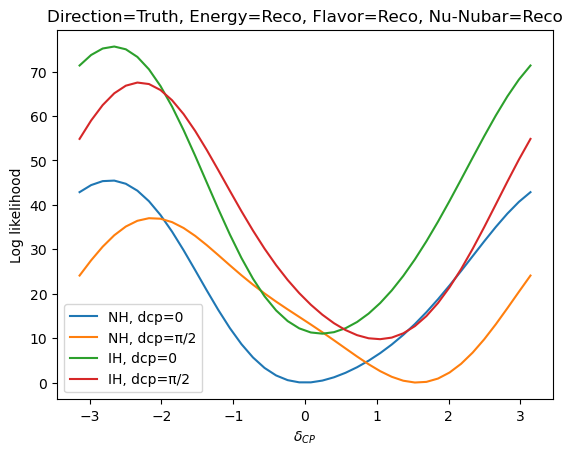

 12%|█▎        | 2/16 [01:10<07:51, 33.69s/it]

Filling histograms...
Using the following detected output channels: ['NC', 'NuE', 'NuMu']
Finished filling histograms...


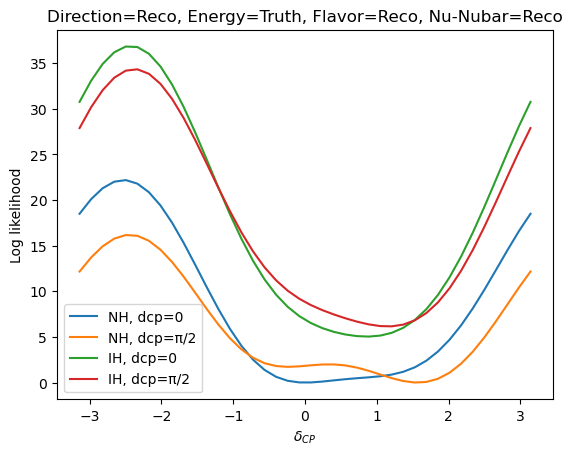

 19%|█▉        | 3/16 [01:40<06:55, 31.94s/it]

Filling histograms...
Using the following detected output channels: ['NC', 'NuE', 'NuMu']
Finished filling histograms...


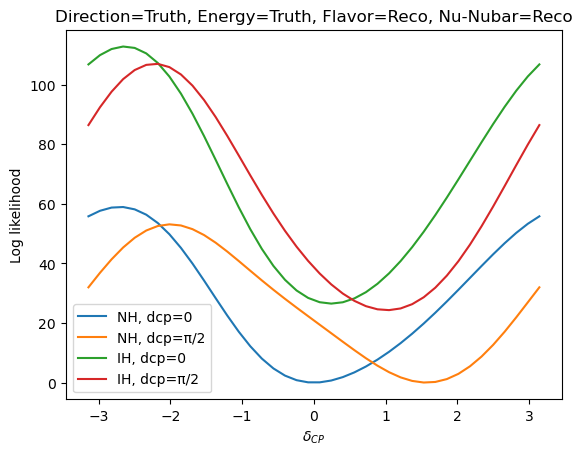

 25%|██▌       | 4/16 [01:57<05:15, 26.29s/it]

Filling histograms...
Using the following detected output channels: ['NuTauBar', 'NuMuBar', 'NuEBar', 'NuE', 'NuMu', 'NuTau']
Finished filling histograms...


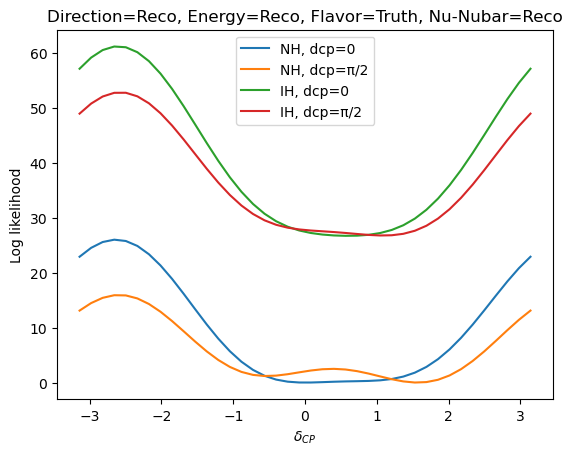

 31%|███▏      | 5/16 [02:50<06:33, 35.79s/it]

Filling histograms...
Using the following detected output channels: ['NuTauBar', 'NuMuBar', 'NuEBar', 'NuE', 'NuMu', 'NuTau']
Finished filling histograms...


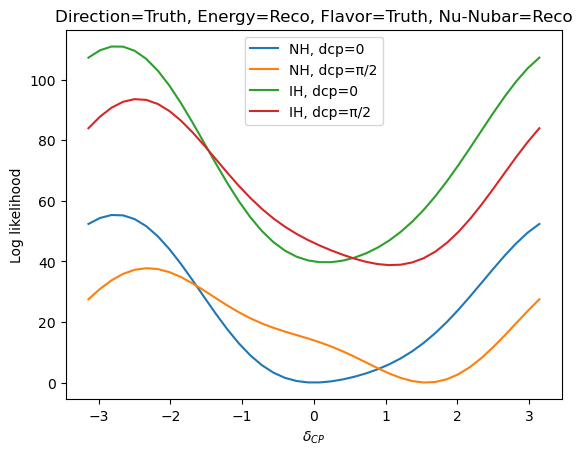

 38%|███▊      | 6/16 [03:33<06:23, 38.36s/it]

Filling histograms...
Using the following detected output channels: ['NuTauBar', 'NuMuBar', 'NuEBar', 'NuE', 'NuMu', 'NuTau']
Finished filling histograms...


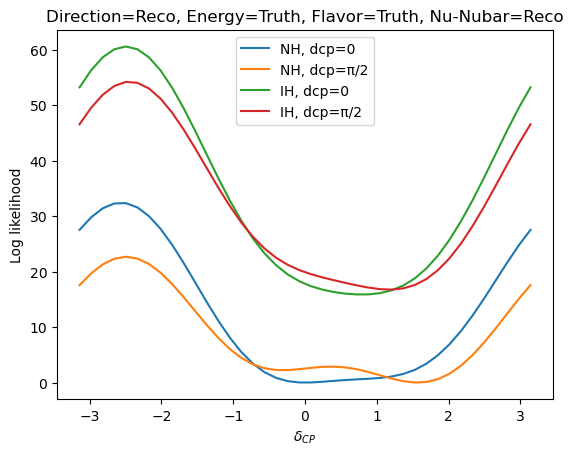

 44%|████▍     | 7/16 [04:21<06:12, 41.38s/it]

Filling histograms...
Using the following detected output channels: ['NuTauBar', 'NuMuBar', 'NuEBar', 'NuE', 'NuMu', 'NuTau']
Finished filling histograms...


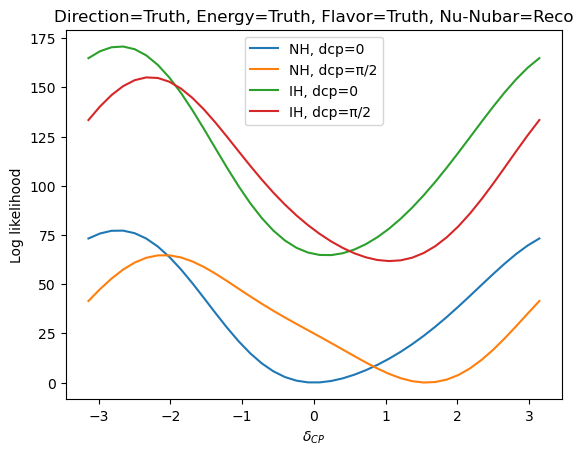

 50%|█████     | 8/16 [04:52<05:04, 38.11s/it]

Filling histograms...
Using the following detected output channels: ['NuMuBar', 'NuEBar', 'NC', 'NuE', 'NuMu']
Finished filling histograms...


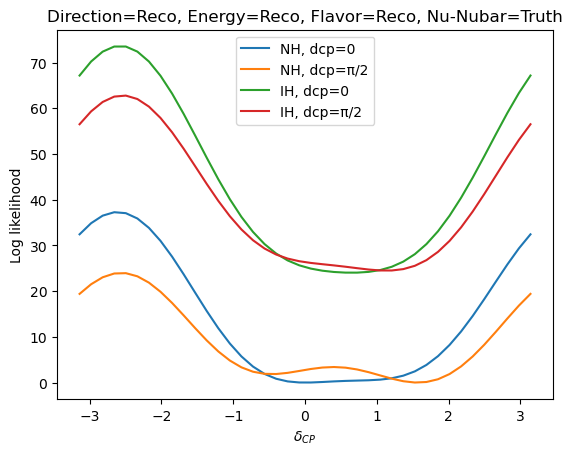

 56%|█████▋    | 9/16 [05:42<04:52, 41.83s/it]

Filling histograms...
Using the following detected output channels: ['NuMuBar', 'NuEBar', 'NC', 'NuE', 'NuMu']
Finished filling histograms...


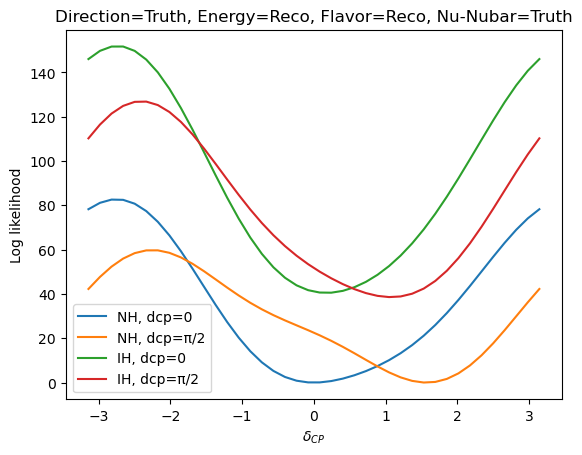

 62%|██████▎   | 10/16 [06:19<04:02, 40.38s/it]

Filling histograms...
Using the following detected output channels: ['NuMuBar', 'NuEBar', 'NC', 'NuE', 'NuMu']
Finished filling histograms...


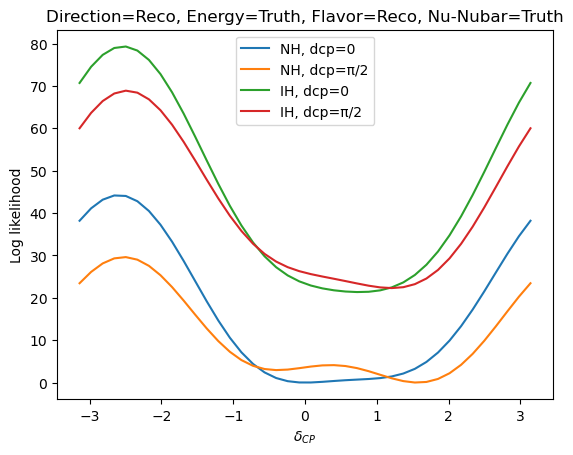

 69%|██████▉   | 11/16 [07:00<03:22, 40.48s/it]

Filling histograms...
Using the following detected output channels: ['NuMuBar', 'NuEBar', 'NC', 'NuE', 'NuMu']
Finished filling histograms...


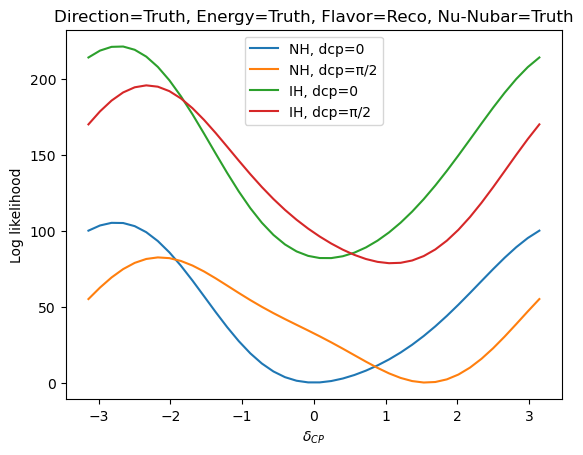

 75%|███████▌  | 12/16 [07:28<02:26, 36.73s/it]

Filling histograms...
Using the following detected output channels: ['NuTauBar', 'NuMuBar', 'NuEBar', 'NuE', 'NuMu', 'NuTau']
Finished filling histograms...


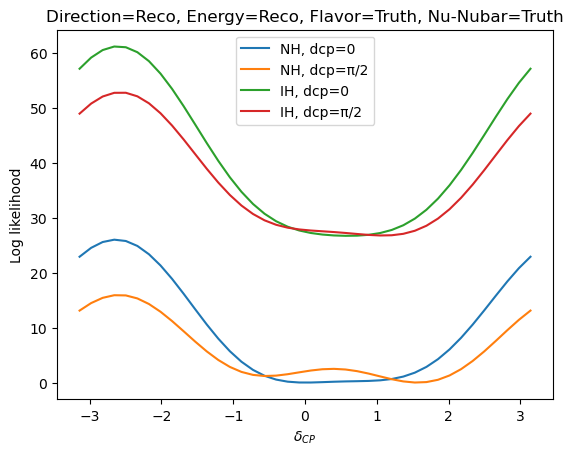

 81%|████████▏ | 13/16 [08:21<02:05, 41.72s/it]

Filling histograms...
Using the following detected output channels: ['NuTauBar', 'NuMuBar', 'NuEBar', 'NuE', 'NuMu', 'NuTau']
Finished filling histograms...


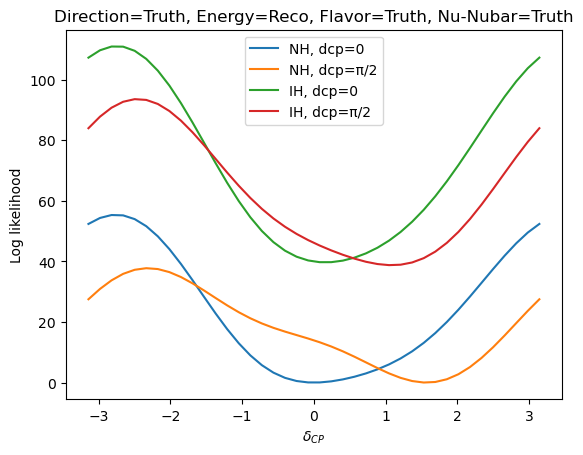

 88%|████████▊ | 14/16 [09:02<01:23, 41.57s/it]

Filling histograms...
Using the following detected output channels: ['NuTauBar', 'NuMuBar', 'NuEBar', 'NuE', 'NuMu', 'NuTau']
Finished filling histograms...


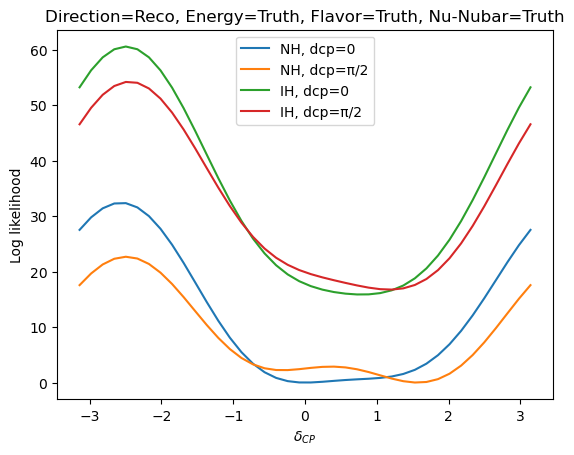

 94%|█████████▍| 15/16 [09:48<00:42, 42.71s/it]

Filling histograms...
Using the following detected output channels: ['NuTauBar', 'NuMuBar', 'NuEBar', 'NuE', 'NuMu', 'NuTau']
Finished filling histograms...


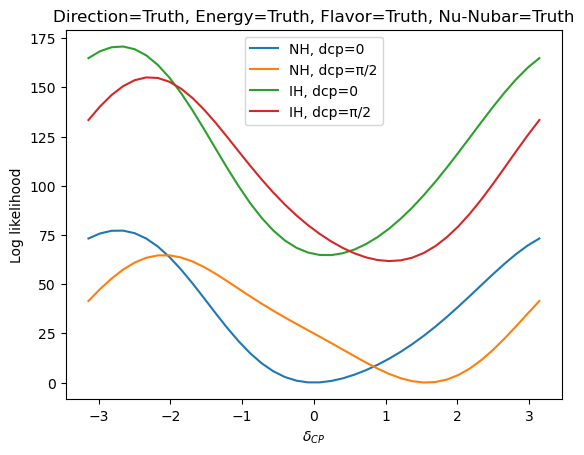

100%|██████████| 16/16 [10:19<00:00, 38.72s/it]


In [5]:
for i in tqdm(range(0b0000, 0b10000)):
    plot_data(i)

In [6]:
def plot_data(method: int, flavors: dict[Flavor, int|float], plot_sum=True):
    direc_reco = Method.Truth if method & 1 << 0 else Method.Reco
    energy_reco = Method.Truth if method & 1 << 1 else Method.Reco
    flavor_disc = Method.Truth if method & 1 << 2 else Method.Reco

    data_manager.set_direc_reco(direc_reco)
    data_manager.set_energy_reco(energy_reco)
    data_manager.set_flavor_discrimination(flavor_disc)

    efficiencies = {
        Flavor.NuE: flavors.get(Flavor.NuE, 1),
        Flavor.NuEBar: flavors.get(Flavor.NuEBar, 1),
        Flavor.NuMu: flavors.get(Flavor.NuMu, 1),
        Flavor.NuMuBar: flavors.get(Flavor.NuMuBar, 1),
        Flavor.NuTau: flavors.get(Flavor.NuTau, 1),
        Flavor.NuTauBar: flavors.get(Flavor.NuTauBar, 1),
        Flavor.NC: flavors.get(Flavor.NC, 1),
    }
    nunubar = FakeEfficiency(efficiencies)
    data_manager.set_nunubar_discrimination(Method.Efficiency, nunubar)
    data = data_manager.prepare_data()
    events = EventDistrib(data, Ebins, Czbins, Ebins_reco, Czbins_reco)

    #Gets the standard oscillation parameters
    pars = get_nufit(MH.Normal)
    #Compute the events with the standard oscillation parameters
    events.compute_osc(pars)
    #Saving the reference event rates
    ref_event_rates = {fl: events.detected_events(fl) for fl in events.detected_channels}

    LnL_values = {fl: [] for fl in events.detected_channels}

    #Sampling dcp values
    sampling = np.linspace(0, 2*np.pi, 50)
    for val in sampling:
        #Setting the dcp value
        pars.dcp = val
        #Computing the events with the new dcp value
        events.compute_osc(pars)
        #Saving the expected event rates
        expected = {fl: events.detected_events(fl) for fl in events.detected_channels}

        #Computing the LnL values
        for ch in events.detected_channels:
            LnL_values[ch].append(LnL(ref_event_rates[ch], expected[ch]))

    #Converting the lists to numpy arrays
    LnL_values = {fl: np.array(values) for fl, values in LnL_values.items()}
    
    
    sum = 0
    for ch, values in LnL_values.items():
        if not ch in flavors:
            continue

        if plot_sum:
            sum += values

        plt.plot(sampling, values, label=latex_names[ch])

    if plot_sum:
        plt.plot(sampling, sum, label="Sum")
    plt.xlabel(r'$\delta_{CP}$')
    plt.ylabel('Log likelihood')
    plt.title(f"Direction={direc_reco.name}, Energy={energy_reco.name}, Flavor={flavor_disc.name}")
    plt.legend()

  0%|          | 0/8 [00:00<?, ?it/s]

Filling histograms...
Using the following detected output channels: ['NuMuBar', 'NuEBar', 'NC', 'NuE', 'NuMu']


Finished filling histograms...


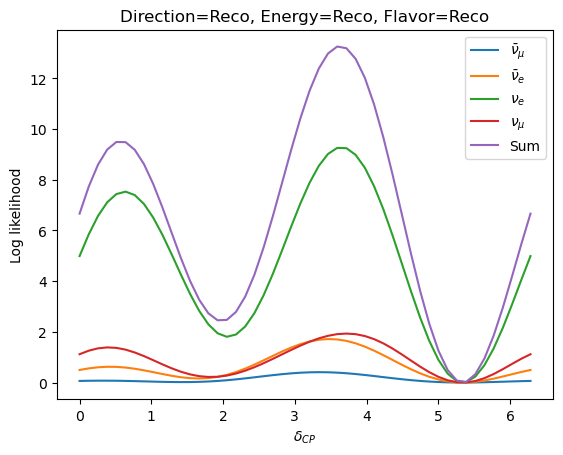

 12%|█▎        | 1/8 [00:49<05:46, 49.53s/it]

Filling histograms...
Using the following detected output channels: ['NuMuBar', 'NuEBar', 'NC', 'NuE', 'NuMu']
Finished filling histograms...


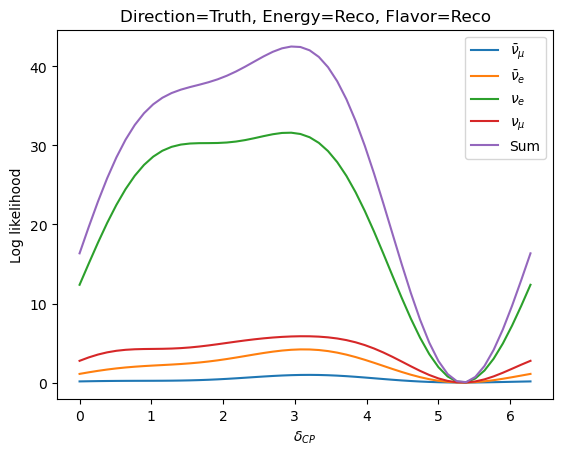

 25%|██▌       | 2/8 [01:24<04:05, 40.97s/it]

Filling histograms...
Using the following detected output channels: ['NuMuBar', 'NuEBar', 'NC', 'NuE', 'NuMu']
Finished filling histograms...


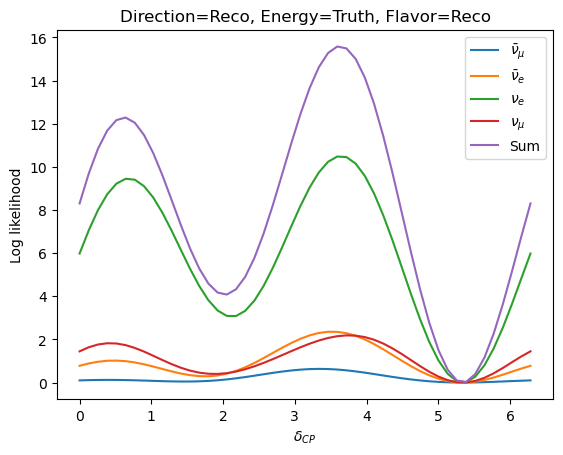

 38%|███▊      | 3/8 [02:03<03:20, 40.07s/it]

Filling histograms...
Using the following detected output channels: ['NuMuBar', 'NuEBar', 'NC', 'NuE', 'NuMu']
Finished filling histograms...


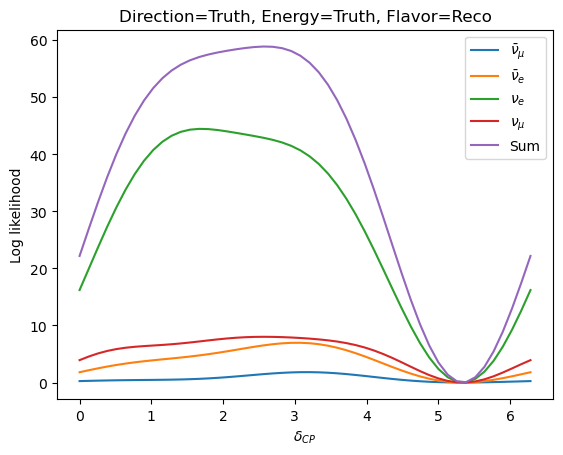

 50%|█████     | 4/8 [02:28<02:15, 33.93s/it]

Filling histograms...
Using the following detected output channels: ['NuTauBar', 'NuMuBar', 'NuEBar', 'NuE', 'NuMu', 'NuTau']
Finished filling histograms...


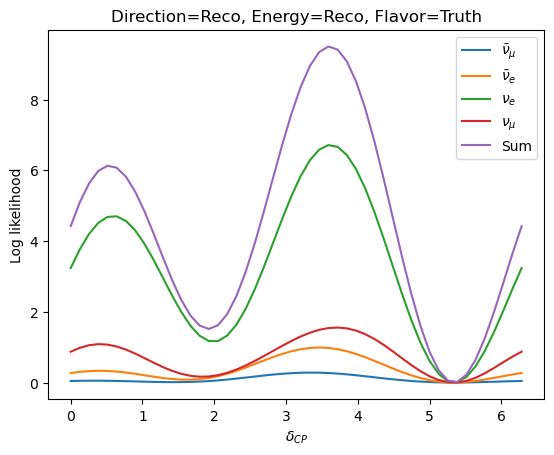

 62%|██████▎   | 5/8 [03:20<02:01, 40.53s/it]

Filling histograms...
Using the following detected output channels: ['NuTauBar', 'NuMuBar', 'NuEBar', 'NuE', 'NuMu', 'NuTau']
Finished filling histograms...


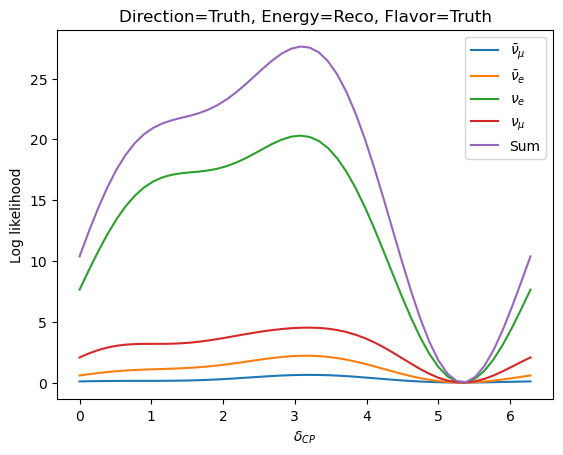

 75%|███████▌  | 6/8 [03:58<01:19, 39.74s/it]

Filling histograms...
Using the following detected output channels: ['NuTauBar', 'NuMuBar', 'NuEBar', 'NuE', 'NuMu', 'NuTau']
Finished filling histograms...


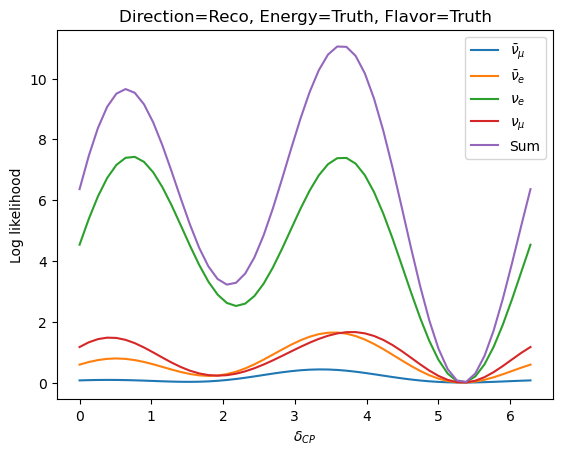

 88%|████████▊ | 7/8 [04:43<00:41, 41.37s/it]

Filling histograms...
Using the following detected output channels: ['NuTauBar', 'NuMuBar', 'NuEBar', 'NuE', 'NuMu', 'NuTau']
Finished filling histograms...


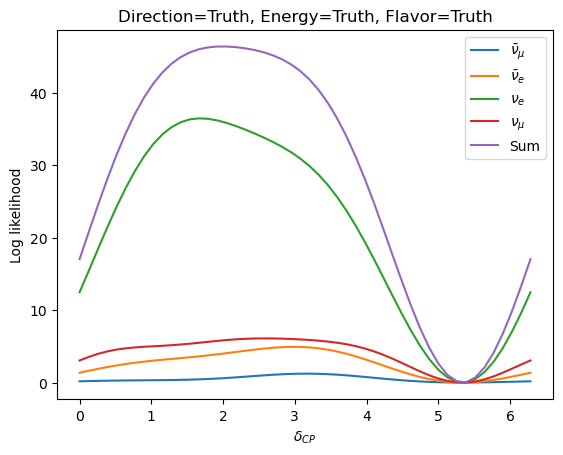

100%|██████████| 8/8 [05:11<00:00, 38.92s/it]


In [7]:
for i in tqdm(range(0b000, 0b1000)):
    plt.figure()
    plot_data(i, {
        Flavor.NuE: 1,
        Flavor.NuEBar: 1,
        Flavor.NuMu: 1,
        Flavor.NuMuBar: 1
    })
    plt.show()

  0%|          | 0/8 [00:00<?, ?it/s]

Filling histograms...
Using the following detected output channels: ['NuMuBar', 'NuEBar', 'NC', 'NuE', 'NuMu']
Finished filling histograms...


 12%|█▎        | 1/8 [00:50<05:50, 50.08s/it]

Filling histograms...
Using the following detected output channels: ['NuMuBar', 'NuEBar', 'NC', 'NuE', 'NuMu']
Finished filling histograms...


 25%|██▌       | 2/8 [01:24<04:06, 41.04s/it]

...

 75%|███████▌  | 6/8 [03:59<01:19, 39.88s/it]

Filling histograms...
Using the following detected output channels: ['NuTauBar', 'NuMuBar', 'NuEBar', 'NuE', 'NuMu', 'NuTau']
Finished filling histograms...


 88%|████████▊ | 7/8 [04:42<00:40, 40.80s/it]

Filling histograms...
Using the following detected output channels: ['NuTauBar', 'NuMuBar', 'NuEBar', 'NuE', 'NuMu', 'NuTau']
Finished filling histograms...


100%|██████████| 8/8 [05:08<00:00, 38.56s/it]


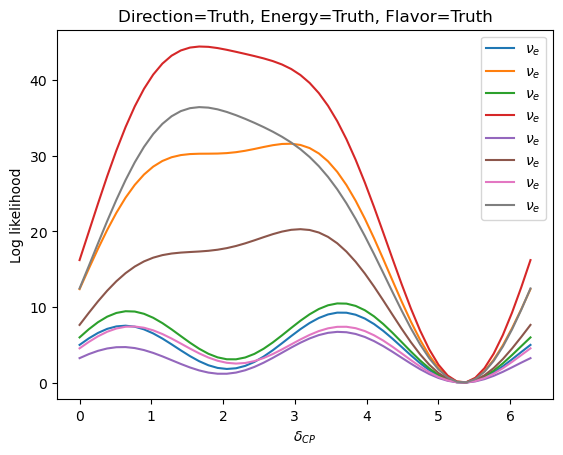

In [8]:
plt.figure()
for i in tqdm(range(0b000, 0b1000)):
    plot_data(i, {Flavor.NuE: 1}, False)
plt.show()